<img src="https://github.com/pavlek358/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Handling Missing Data in Python

---

### About
In this notebook, we will explore various techniques for identifying, visualizing, and handling missing data in Python using `pandas` and other libraries. Missing data is a common challenge in real-world data sets, and understanding how to address it effectively is a crucial skill for data analysis.

### Learning Objectives
- Identify and visualize missing data
- Understand patterns of missingness
- Implement deletion methods
- Apply simple imputation techniques
- Evaluate the impact of different approaches

### Notebook Guide
1. Setup and Load Data
2. Identifying Missing Data
3. Deletion Methods
4. Simple Imputation Methods
5. Imputation Based on Other Variables
6. Handling Mixed Data Types
7. Best Practices and Conclusion
8. Now You Try
9. Conclusion

# 1. Setup and Load Data

In [ ]:
# !pip install missingno

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization of missing data
import missingno as msno

# For evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set the random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Let's load a data set with missing values to work with. We'll use a modified version of the Titanic data set.

In [4]:
# Load the Titanic data set
url="https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/data/titanic-adj.csv"
titanic_df=pd.read_csv(url)

In [5]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# 2. Identifying Missing Data

The first step in handling missing data is to identify and understand the extent of missingness in your data set.

In [7]:
# Check for missing values in each column
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
# Calculate the percentage of missing values in each column
titanic_df.isnull().mean()*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


### Visualizing Missing Data

Visualization can help identify patterns in missingness. The [`missingno`](https://github.com/ResidentMario/missingno) library is particularly useful for this purpose.

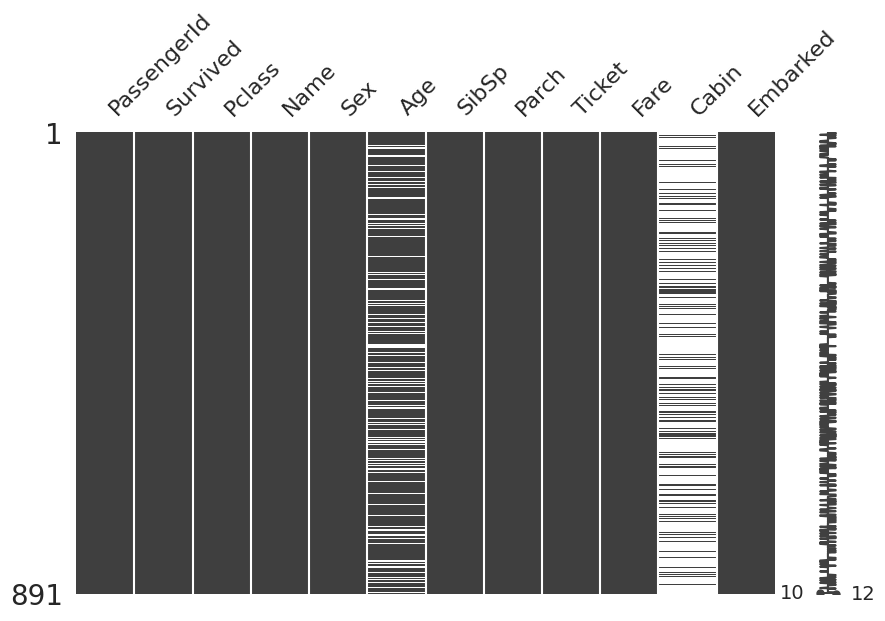

In [14]:
# Create a matrix visualization of missing values
msno.matrix((titanic_df), figsize=(10,6));

<Axes: >

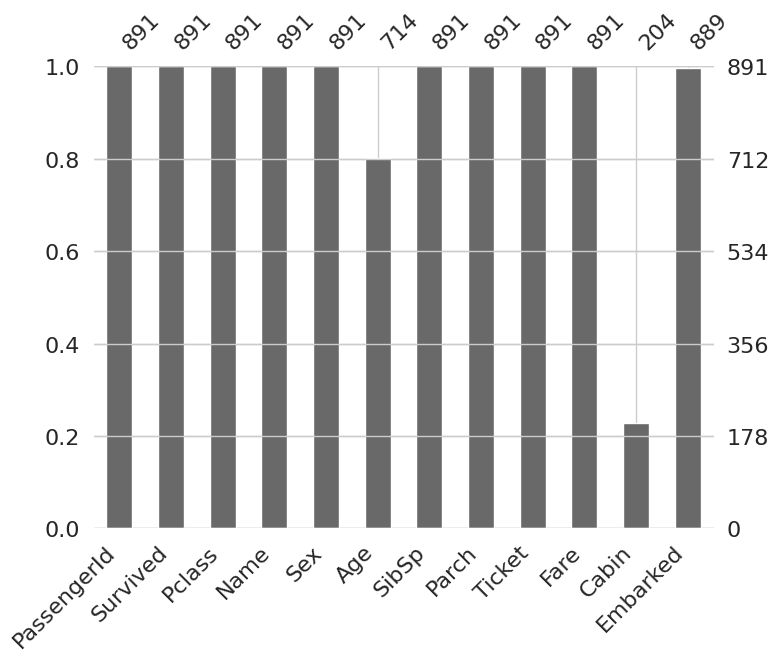

In [15]:
# Create a bar chart showing the count of missing values by column
msno.bar(titanic_df, figsize=(8, 6))

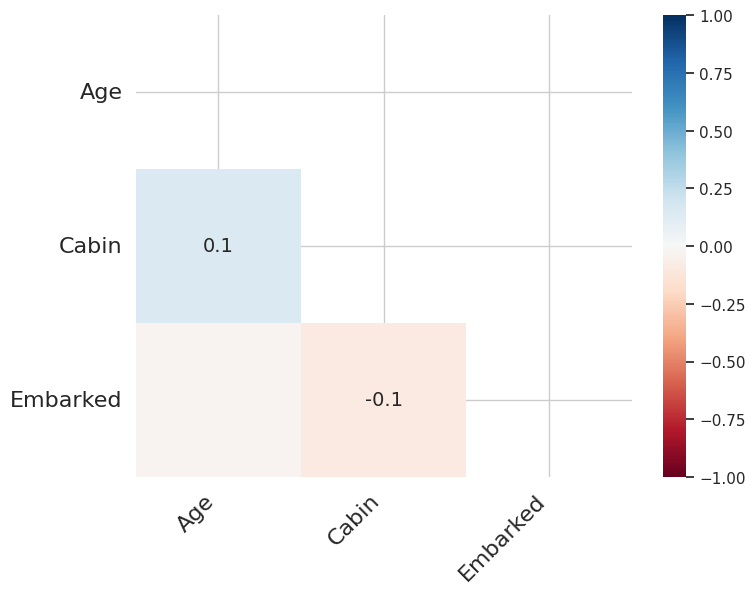

In [16]:
# Create a heatmap to show correlations between missingness
msno.heatmap(titanic_df,figsize=(8,6));

### What patterns of missingness can you see in the Titanic data set? Are there any relationships between missing values in different columns?

---Back to the slides!---

# 3. Deletion Methods

The simplest approach to handling missing data is to remove observations or variables with missing values.

### 3.1 Listwise Deletion (Complete-case analysis)

In [20]:
# Remove all rows with any missing values
# Check how many rows remain

df_listwise_delted_titanic = titanic_df.dropna()

In [21]:
df_listwise_delted_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [35]:
print(f"Original Titatanic data set size:{len(titanic_df)}")
print(f"New Titatanic data set size:{len(df_listwise_delted_titanic)}")
print(f"Percentage of data kept:{len(titanic_df)}/{len(df_listwise_delted_titanic)*100:.2f}%")


Original Titatanic data set size:891
New Titatanic data set size:183
Percentage of data kept:891/18300.00%


### 3.2 Column Deletion

In [33]:
# Create a copy of the original data set
# Remove columns with more than 30% missing values
# Print the remaining columns
df_column_deleted_titanic = titanic_df.copy()
treshold=0.3,
df_listwise_delted_titanic = df_column_deleted_titanic.loc[:df_column_deleted_titanic.isnull()mean()<treshhold]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (918888639.py, line 6)

### 3.3 Dropping specific columns

Sometimes, we decide to drop specific columns based on domain knowledge or analysis requirements.

In [34]:
# Drop the 'Cabin' column
# Drop rows where 'Age' is missing, but keep rows with missing values in other columns
df_titanic_age_complete = titanic_df.dropna(subset=['Age'])

# Check how many rows remain
print(f"Original Titanic data set size: {len(titanic_df)}")
print(f"Listwise Titanic data set size: {len(df_titanic_age_complete)}")
print(f"Percentage of data kept: {(len(df_titanic_age_complete) / len(titanic_df) * 100):.2f}%")

Original Titanic data set size: 891
Listwise Titanic data set size: 714
Percentage of data kept: 80.13%


### 3.4 Dropping specific rows (subset of columns)

In [ ]:
# Drop rows where 'Age' is missing, but keep rows with missing values in other columns
# Check how many rows remain


### What are the advantages and disadvantages of the deletion methods you've implemented above?

---Back to the slides!---

# 4. Simple Imputation Methods

Instead of deleting data, we can replace missing values with estimates.

### 4.1 Mean/Median/Mode Imputation

In [39]:
# Create a copy of the original data set
df_titanic_imputed = titanic_df.copy()
# Impute missing values in the 'Age' column with the mean
mean_age = df_titanic_imputed['Age'].mean()
df_titanic_imputed['Age']=df_titanic_imputed['Age'].fillna(mean_age)
# Check that there are no missing values in the 'Age' column
print(f"Missing values in Age column:{df_titanic_imputed['Age'].isnull().sum()}")

Missing values in Age column:0


In [ ]:
# Create a copy of the original data set
# Impute missing values in the 'Age' column with the median
# Check that there are no missing values in the 'Age' column


In [ ]:
# Create a copy of the original data set
# Impute missing values in the 'Embarked' column with the mode
# Check that there are no missing values in the 'Embarked' column


Let's compare the distribution of `Age` before and after imputation.

In [ ]:
# Compare the original and imputed age distributions
# Original age distribution (excluding missing values)
# Mean imputed age distribution
# Median imputed age distribution


### 4.2 Constant Value Imputation

In [ ]:
# Create a copy of the original data set
# Impute missing 'Cabin' values with 'Unknown'
# Check the result


### How do mean/median/mode imputation and constant imputation affect the distribution of the data? What are potential issues with these methods?

# 5. Imputation Based on Other Variables

More sophisticated imputation methods leverage relationships between variables to estimate missing values.

### 5.1 Imputation by Group

In [ ]:
# Create a copy of the original data set
# Group passengers by class and gender, then impute age with the group mean
# Check if there are any missing age values left


Let's compare the age distribution after group imputation with the original data.

In [ ]:
# Compare the original and group-imputed age distributions
# Plot histograms


### 5.2 Adding Missing Indicators

Creating indicator variables for missingness can help preserve information about the pattern of missing data.

In [ ]:
# Create a copy of the original data set
# Add missing indicators for 'Age' and 'Cabin'
# Impute missing values
# Check the result


---Back to the slides!---

# 6. Handling Mixed Data Types

Real-world data sets often contain a mix of numerical and categorical variables. Let's implement a complete missing data handling strategy for the Titanic data set.

In [ ]:
# Create a copy of the original data set
# Examine the data types


In [ ]:
# Implement a complete missing data strategy
# 1. Drop columns with too many missing values
# 2. Handle numerical variables
# Group passengers by class and gender for more accurate imputation
    # Calculate group means
    # Impute missing values with group means
    # For any remaining missing values (rare groups), use overall mean
# 3. Handle categorical variables
# Impute 'Embarked' with mode
# 4. Check if there are any missing values left


# 7. Best Practices and Conclusion

Let's summarize best practices for handling missing data in Python:

### Best Practices for Handling Missing Data

1. **Understand the data**: Always start by exploring the extent and patterns of missingness.
2. **Consider the missingness mechanism**: Is the data MCAR, MAR, or MNAR? This influences your choice of handling method.
3. **Document your approach**: Keep track of how you handled missing data for transparency and reproducibility.
4. **Use appropriate methods for different variables**: Consider the type and importance of each variable.
5. **Create missing indicators**: For key variables, create indicator variables to preserve information about missingness.
6. **Compare different approaches**: Evaluate the impact of different methods on your analysis or model.
7. **Consider domain knowledge**: Incorporate subject matter expertise in your imputation strategy.
8. **Be cautious with deletion methods**: Only use deletion when data is MCAR or the amount of missingness is very small.
9. **Conduct sensitivity analysis**: Test how sensitive your conclusions are to different missing data handling approaches.

# 8. Now You Try

1. Load a data set of your choice (you can use any that we have seen so far, or one of your own) and identify missing values.
2. Visualize the pattern of missingness using `missingno`.
3. Implement at least three different imputation methods.
4. Evaluate and compare the methods based on their effect on your analysis results or model performance.
5. Develop a comprehensive strategy for handling missing data in the data set, taking into account the variable types and missingness patterns.

# 9. Conclusion

In this notebook, we've explored various techniques for handling missing data in Python using pandas and other libraries. We've learned how to identify, visualize, and address missing values using deletion and imputation methods. Remember that there's no one-size-fits-all approach to handling missing data, and the best strategy depends on the specific characteristics of your data set and the goals of your analysis.